In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/crowdflower/twitter-airline-sentiment/Tweets.csv
/kaggle/input/datasets/organizations/crowdflower/twitter-airline-sentiment/database.sqlite


In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv('/kaggle/input/datasets/organizations/crowdflower/twitter-airline-sentiment/Tweets.csv')
print('Shape:', df.shape)
df.head(3)

Shape: (14640, 15)


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)


In [4]:
df = df[['text', 'airline_sentiment']].dropna()
df.columns = ['text', 'label']
df['text'] = df['text'].astype(str).str.strip()

label_list = sorted(df['label'].unique().tolist())
label2id   = {l: i for i, l in enumerate(label_list)}
id2label   = {i: l for l, i in label2id.items()}
df['label'] = df['label'].map(label2id)

print('Label mapping:', label2id)
print(df['label'].value_counts())

Label mapping: {'negative': 0, 'neutral': 1, 'positive': 2}
label
0    9178
1    3099
2    2363
Name: count, dtype: int64


In [5]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

if len(df) < 12000:
    times = int(np.ceil(12000 / len(df)))
    df = pd.concat([df]*times, ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
    print(f'Repeated to {len(df)} rows')

df_train = df.iloc[:8000].reset_index(drop=True)
df_val   = df.iloc[8000:10000].reset_index(drop=True)
df_test  = df.iloc[10000:12000].reset_index(drop=True)

print(f'Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}')

Train: 8000 | Val: 2000 | Test: 2000


In [6]:
from datasets import Dataset

train_hf = Dataset.from_pandas(df_train)
val_hf   = Dataset.from_pandas(df_val)
test_hf  = Dataset.from_pandas(df_test)

print(train_hf)
print(val_hf)

Dataset({
    features: ['text', 'label'],
    num_rows: 8000
})
Dataset({
    features: ['text', 'label'],
    num_rows: 2000
})


In [7]:
from transformers import AutoTokenizer

MODEL_NAME = 'Qwen/Qwen2.5-0.5B'

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

def tokenize(batch):
    return tokenizer(batch['text'], max_length=128, padding='max_length', truncation=True)

train_hf = train_hf.map(tokenize, batched=True)
val_hf   = val_hf.map(tokenize,   batched=True)
test_hf  = test_hf.map(tokenize,  batched=True)

# Rename label column to what HuggingFace Trainer expects
train_hf = train_hf.rename_column('label', 'labels')
val_hf   = val_hf.rename_column('label', 'labels')
test_hf  = test_hf.rename_column('label', 'labels')

# Set format for PyTorch
train_hf.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
val_hf.set_format('torch',   columns=['input_ids', 'attention_mask', 'labels'])
test_hf.set_format('torch',  columns=['input_ids', 'attention_mask', 'labels'])

print('Tokenization done!')

config.json:   0%|          | 0.00/681 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Tokenization done!


In [8]:
from transformers import AutoModelForSequenceClassification
from peft import LoraConfig, get_peft_model, TaskType

print('Loading model...')
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id,
    trust_remote_code=True,
    ignore_mismatched_sizes=True
)
model.config.pad_token_id = tokenizer.pad_token_id

# Apply LoRA using HuggingFace PEFT
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    target_modules=['q_proj', 'v_proj'],
    bias='none'
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()  # Shows how few params LoRA trains

Loading model...


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-0.5B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 543,360 || all params: 494,578,816 || trainable%: 0.1099


In [9]:
!pip install -q transformers peft accelerate scikit-learn seaborn openpyxl evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.8 MB/s eta 0:00:00


In [10]:
from transformers import TrainingArguments, Trainer
import evaluate
import numpy as np

accuracy = evaluate.load('accuracy')



In [11]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return accuracy.compute(predictions=predictions, references=labels)

In [12]:
training_args = TrainingArguments(
    output_dir='./lora_output',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=4,   # Method 2: Gradient Accumulation
    learning_rate=2e-4,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    logging_steps=50,
    report_to='none'
)

In [13]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_hf,
    eval_dataset=val_hf,
    compute_metrics=compute_metrics,
)

In [14]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy
1,9.247930,1.159125,0.795500
2,3.851328,0.900187,0.830000
3,3.216855,0.860313,0.832000
4,2.715820,0.833625,0.842000
5,2.512832,0.833188,0.841500


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector

TrainOutput(global_step=315, training_loss=3.9900824652777778, metrics={'train_runtime': 2380.6854, 'train_samples_per_second': 16.802, 'train_steps_per_second': 0.132, 'total_flos': 1.10114045952e+16, 'train_loss': 3.9900824652777778, 'epoch': 5.0})

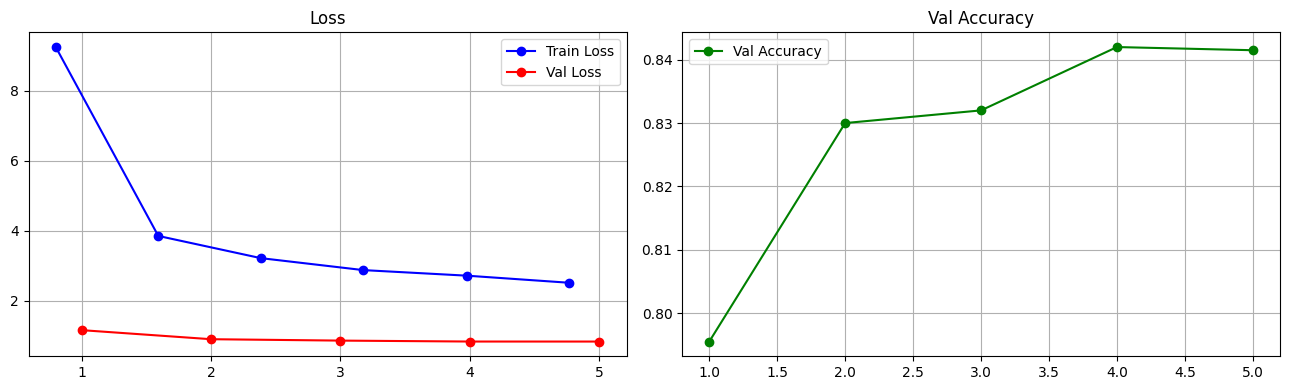

In [15]:
import matplotlib.pyplot as plt

logs = trainer.state.log_history

train_loss = [(x['epoch'], x['loss'])       for x in logs if 'loss' in x and 'eval_loss' not in x]
val_loss   = [(x['epoch'], x['eval_loss'])   for x in logs if 'eval_loss' in x]
val_acc    = [(x['epoch'], x['eval_accuracy']) for x in logs if 'eval_accuracy' in x]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(*zip(*train_loss), 'b-o', label='Train Loss')
axes[0].plot(*zip(*val_loss),   'r-o', label='Val Loss')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(*zip(*val_acc), 'g-o', label='Val Accuracy')
axes[1].set_title('Val Accuracy'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

In [16]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

predictions = trainer.predict(test_hf)
preds  = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

pred_names  = [id2label[p] for p in preds]
label_names = [id2label[l] for l in labels]

print('=== Test Set Results ===')
print(classification_report(label_names, pred_names))

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


=== Test Set Results ===
              precision    recall  f1-score   support

    negative       0.87      0.92      0.90      1198
     neutral       0.70      0.63      0.67       468
    positive       0.81      0.76      0.79       334

    accuracy                           0.83      2000
   macro avg       0.80      0.77      0.78      2000
weighted avg       0.82      0.83      0.83      2000



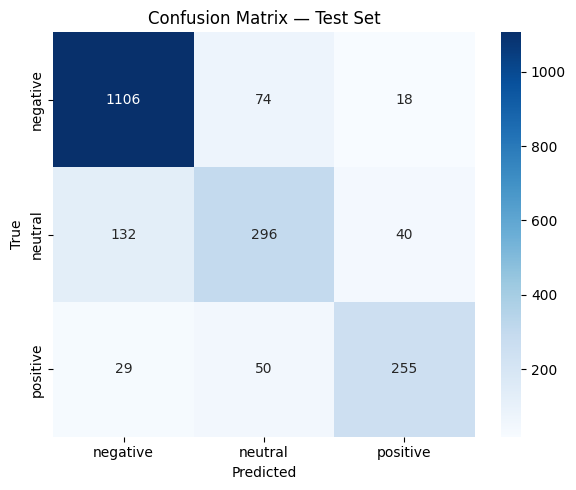

In [17]:
cm = confusion_matrix(label_names, pred_names, labels=label_list)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_list, yticklabels=label_list)
plt.title('Confusion Matrix — Test Set')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [18]:
model.save_pretrained('./best_lora_model')
tokenizer.save_pretrained('./best_lora_model')

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
best_acc  = max(x['eval_accuracy'] for x in logs if 'eval_accuracy' in x)

print('='*50)
print('FINAL SUMMARY')
print('='*50)
print(f'Base Model:   Qwen2.5-0.5B')
print(f'Method 1:     LoRA  (rank=8, alpha=16)')
print(f'Method 2:     Gradient Accumulation (steps=4)')
print(f'Split:        8000 / 2000 / 2000')
print(f'Epochs:       10')
print(f'Best Val Acc: {best_acc:.4f}')
print(f'Trainable:    {trainable:,} / {total:,} ({100*trainable/total:.2f}%)')
print('='*50)

FINAL SUMMARY
Base Model:   Qwen2.5-0.5B
Method 1:     LoRA  (rank=8, alpha=16)
Method 2:     Gradient Accumulation (steps=4)
Split:        8000 / 2000 / 2000
Epochs:       10
Best Val Acc: 0.8420
Trainable:    543,360 / 494,578,816 (0.11%)
